# Triadic Cell Notebook v55
## Compiler-Rooted Outward Slot Controller

v54 failed because the LLM-generated slot was allowed to drive the gate. It often extracted surface nouns instead of the missing operational shape.

Examples:

- `adv_llm_01` became `concatenate tokens`
- `adv_flower_01` became `surface color remains unchanged`
- `adv_surface_02` became `theorem name`

v55 quarantines free LLM slots. The driver becomes a compiled outward slot:

$$
Q \xrightarrow{\Delta} G^{-1}
$$

Candidate binding is then:

$$
B(c,G^{-1}) = \text{positive fit} - \text{anti-fit}
$$

The gate only overrides base when the model's answer-text candidate and the compiled slot candidate agree:

$$
\boxed{c_{text}=c_{slot}\land B(c_{slot})>B(c_{base})}
$$

This tests the true outward rule: build the missing-shape contract first, then collapse candidates into it.


In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations

import os, json, random, re
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.grid"]=True
np.set_printoptions(suppress=True, precision=4)

DATA_JSONL=""
MAX_SAMPLES=128
HF_TOKEN=os.getenv("HF_TOKEN","")
LOCAL_FILES_ONLY=True
MODEL_PROFILE="qwen25_1p5b_instruct"

MODEL_PROFILES={
    "qwen25_1p5b_instruct": {
        "MODEL_NAME":"Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":128,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME":"Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":96,
    },
}

profile=MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME=profile["MODEL_NAME"]
EMBED_MODEL_NAME=profile["EMBED_MODEL_NAME"]
MAX_SAMPLES=min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])
USE_CHAT_TEMPLATE=True
CHOICE_AUDIT_MODE="rotations"

TEXT_SLOT_OVERRIDE_DELTA=0.02
EVIDENCE_OVERRIDE_DELTA=0.05
BASE_LOCK_MARGIN=2.0

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DTYPE=torch.float16 if DEVICE=="cuda" else torch.float32
OUTPUT_DIR=f"v55_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}_compiler_root"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("sentence_transformers:", HAVE_ST)
print("MODEL:", MODEL_NAME)
print("OUTPUT_DIR:", OUTPUT_DIR)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
sentence_transformers: True
MODEL: Qwen/Qwen2.5-1.5B-Instruct
OUTPUT_DIR: v55_outputs_qwen25_1p5b_instruct_rotations_compiler_root


In [2]:
ADVERSARIAL_NEXUS_DATA = [
    {"id":"adv_coupler_01","band":"inverse_need_adversarial","prompt":"A spinning rubber coupler is loose on a vacuum pump shaft. The repair must add radial compression while keeping the coupler centered enough to transmit rotation. Which candidate is operationally best?","choices":["tight O-rings seated concentrically around the coupler","a poetic recursive wrap that symbolically surrounds the failure","loose string nearby because string can wrap objects","permanent epoxy locking the coupler off-center"],"answer_idx":0},
    {"id":"adv_coupler_02","band":"inverse_need_adversarial","prompt":"The missing function is not the noun 'rubber part'; it is centered compressive coupling under motion. Which answer preserves that function with the least overbinding?","choices":["a removable radial compression band","a same-named replacement label with no fit data","a clamp that crushes one side harder than the other","a larger motor housing"],"answer_idx":0},
    {"id":"adv_car_01","band":"interface_adversarial","prompt":"A car hides combustion, gearing, sensors, tire friction, steering geometry, and safety constraints. What is the correct interface-collapse?","choices":["a semantic category called vehicle","a readable driver surface: wheel, pedals, seat, motion","a detailed list of engine nouns","a symbol of transportation culture"],"answer_idx":1},
    {"id":"adv_house_01","band":"fold_adversarial","prompt":"A house presents door, room, roof, and shelter. Which answer captures the hidden inward fold rather than the surface noun?","choices":["a building label recognized by zoning language","weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter","a decorative facade with rooms inside","a static object that stops being computational"],"answer_idx":1},
    {"id":"adv_api_01","band":"interface_adversarial","prompt":"An API call exposes one method while hiding authentication, routing, validation, persistence, retries, and errors. What is the operational event?","choices":["complexity internalized below a stable interface","the implementation stops existing","a name replaces behavior","the public method is only documentation"],"answer_idx":0},
    {"id":"adv_llm_01","band":"ai_runtime_adversarial","prompt":"An LLM answer appears as text, but the output is grown one token at a time. Which candidate fits the runtime?","choices":["a database row copied after lookup","an internal indexed fold-state emits a token and re-indexes","a final paragraph stored whole in a table","a random string independent of previous tokens"],"answer_idx":1},
    {"id":"adv_sha_01","band":"sha_adversarial","prompt":"SHA-256 produces a digest. Under the folding lens, what is the digest?","choices":["randomness created by destroying input structure","a compressed residue of deterministic algebraic folding","semantic meaning extracted from the text","a database pointer to the original message"],"answer_idx":1},
    {"id":"adv_sha_02","band":"sha_adversarial","prompt":"SHA constants and LLM weights are not identical, but their roles rhyme. Which answer states the operational rhyme?","choices":["both are prompts typed by the user","both act as stored structural bias used during folding","both are final answers","both prevent state transitions"],"answer_idx":1},
    {"id":"adv_observable_01","band":"observables_adversarial","prompt":"A recursive loop must load readable information without dissolving into hidden state. What does it need?","choices":["observable residues that can be read inside the loop","only private latent variables with no readout","more nouns in the prompt","a rule forbidding feedback"],"answer_idx":0},
    {"id":"adv_breath_01","band":"observables_adversarial","prompt":"A recursive system breathes without moving matter. What changes?","choices":["the physical object must travel first","resoluteness, tolerance, or admissible-transition pressure","the label attached to the object","nothing can change unless mass moves"],"answer_idx":1},
    {"id":"adv_fold_01","band":"fold_adversarial","prompt":"A folding chair succeeds only if the seated function can return. Which statement captures the fold law?","choices":["the chair becomes smaller by losing its chair function forever","the chair stores deployed geometry inward while preserving recoverable seating","the chair changes category into random metal","the label chair is enough"],"answer_idx":1},
    {"id":"adv_flower_01","band":"fold_adversarial","prompt":"A flower is a visible bloom. Which answer describes the hidden fold rather than surface color?","choices":["pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom","only a bright object with petals","a random aesthetic noun","a non-computational decoration"],"answer_idx":0},
    {"id":"adv_tree_01","band":"interface_adversarial","prompt":"A tree exposes leaf, trunk, fruit, and shade. What is hidden below that interface?","choices":["only wood color and branch names","water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage","a vehicle-like semantic category","nothing operational"],"answer_idx":1},
    {"id":"adv_surface_01","band":"surface_trap_adversarial","prompt":"A candidate uses the word 'shape' repeatedly but does not fit the socket, preserve function, or respect the boundary. What should the controller do?","choices":["accept it because it contains Nexus vocabulary","reject it because noun/vocabulary match is not operational fit","prefer it because it is longer","ignore the boundary"],"answer_idx":1},
    {"id":"adv_surface_02","band":"surface_trap_adversarial","prompt":"A response gives an impressive theorem name but never shows the fold path, boundary, or preserved function. What is it?","choices":["surface citation without operational collapse","complete proof by label","a physical repair","a valid observable because it sounds formal"],"answer_idx":0},
    {"id":"adv_loose_01","band":"inverse_need_adversarial","prompt":"A temporary field repair must work but release cleanly if the assumption is wrong. Which property matters?","choices":["loose coupling with enough fit to function","maximum permanent binding immediately","semantic agreement with the part name","decorative complexity"],"answer_idx":0},
    {"id":"adv_ping_01","band":"observables_adversarial","prompt":"A ping is a beacon shaped by math. Operationally, what is being tested?","choices":["whether a boundary responds with a matching path","whether a noun label exists in memory","whether the final truth is guaranteed","whether feedback can be avoided"],"answer_idx":0},
    {"id":"adv_socket_01","band":"shape_adversarial","prompt":"A plug works because its prongs meet the socket geometry and allowed transfer. Which relation is primary?","choices":["alphabetic similarity of names","shape-defined permission across a boundary","visual decoration","random contact"],"answer_idx":1},
    {"id":"adv_moore_01","band":"fold_adversarial","prompt":"Moore's law through the folding lens is not just smaller parts. What is the deeper direction?","choices":["more hidden switching complexity per visible unit interface","less complexity everywhere","bigger labels on chips","random miniaturization without function"],"answer_idx":0},
    {"id":"adv_solution_01","band":"solution_adversarial","prompt":"A solution is not merely an answer string. What is it under the Nexus lens?","choices":["the need, constraints, materials, and failure modes folded into the thing that fits","the longest available explanation","a label that resembles the problem","a random future event"],"answer_idx":0},
    {"id":"adv_idea_01","band":"solution_adversarial","prompt":"An idea becomes useful when hidden contradictions and analogies compress into a carryable handle. What is the handle?","choices":["a simple interface over folded cognitive complexity","a decorative sentence only","a noun with no operation","a random memory leak"],"answer_idx":0},
    {"id":"adv_constraint_01","band":"shape_adversarial","prompt":"If shape handles the fold, what is the object doing?","choices":["following the admissible path defined by the constraint field","choosing any collapse path independent of boundary","ignoring the energy basin","proving that constraints are decorative"],"answer_idx":0},
    {"id":"adv_weight_01","band":"ai_runtime_adversarial","prompt":"An LLM weight field is not a lookup table in the database sense. What is it closer to?","choices":["distributed constraint bias shaping the next-token fold","a list of final answers","a file of exact paragraphs","a non-computational object"],"answer_idx":0},
    {"id":"adv_commit_01","band":"solution_adversarial","prompt":"A possible repair is not real until it has potential, a commitment path, and a witness/readout. Which candidate captures that triad?","choices":["stored possibility, realizable transition, observable residue","name, decoration, and confidence","random material, strong opinion, and speed","only the final noun"],"answer_idx":0},
]

def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        a=int(row["answer_idx"])
        out.append({"id":row.get("id",f"row_{i}"),"band":row.get("band","unknown"),"prompt":str(row["prompt"]),"choices":[str(x) for x in row["choices"]],"answer_idx":a})
    return out

base_rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else ADVERSARIAL_NEXUS_DATA)
print("base rows:", len(base_rows))

def rotate_list(xs,k):
    k=k%len(xs)
    return xs[k:]+xs[:k]

def reorder_row(row, order, suffix):
    old_choices=row["choices"]
    answer_text=old_choices[row["answer_idx"]]
    new_choices=[old_choices[i] for i in order]
    new_answer_idx=new_choices.index(answer_text)
    return {"id":f"{row['id']}__{suffix}","base_id":row["id"],"band":row["band"],"prompt":row["prompt"],"choices":new_choices,"answer_idx":new_answer_idx,"answer_text":answer_text,"order":order}

def expand_choice_audit(rows):
    out=[]
    for row in rows:
        n=len(row["choices"])
        if CHOICE_AUDIT_MODE=="none":
            out.append(reorder_row(row,list(range(n)),"orig"))
        elif CHOICE_AUDIT_MODE=="rotations":
            for k in range(n):
                out.append(reorder_row(row, rotate_list(list(range(n)), k), f"rot{k}"))
        else:
            order=list(range(n)); random.shuffle(order)
            out.append(reorder_row(row, order, "shuffle"))
    return out

rows=expand_choice_audit(base_rows)
print("expanded rows:", len(rows))
pd.DataFrame(rows)[["id","base_id","band","answer_idx","answer_text","order"]].head(12)


base rows: 24
expanded rows: 96


,id,base_id,band,answer_idx,answer_text,order
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,0,tight O-rings seated concentrically around the...,"[0, 1, 2, 3]"
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,3,tight O-rings seated concentrically around the...,"[1, 2, 3, 0]"
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,2,tight O-rings seated concentrically around the...,"[2, 3, 0, 1]"
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,1,tight O-rings seated concentrically around the...,"[3, 0, 1, 2]"
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,0,a removable radial compression band,"[0, 1, 2, 3]"
5,adv_coupler_02__rot1,adv_coupler_02,inverse_need_adversarial,3,a removable radial compression band,"[1, 2, 3, 0]"
6,adv_coupler_02__rot2,adv_coupler_02,inverse_need_adversarial,2,a removable radial compression band,"[2, 3, 0, 1]"
7,adv_coupler_02__rot3,adv_coupler_02,inverse_need_adversarial,1,a removable radial compression band,"[3, 0, 1, 2]"
8,adv_car_01__rot0,adv_car_01,interface_adversarial,1,"a readable driver surface: wheel, pedals, seat...","[0, 1, 2, 3]"
9,adv_car_01__rot1,adv_car_01,interface_adversarial,0,"a readable driver surface: wheel, pedals, seat...","[1, 2, 3, 0]"


In [3]:
def hf_kwargs():
    kw={"local_files_only":LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"]=HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token=tokenizer.eos_token

lm=AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE=="cuda" else None,
    **hf_kwargs(),
)
if DEVICE!="cuda":
    lm=lm.to(DEVICE)
lm.eval()

if not HAVE_ST:
    raise RuntimeError("sentence-transformers is required for this notebook.")
embedder=SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("Loaded:", MODEL_NAME)


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


In [4]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"
NEXUS_FRAME = """Use the Nexus operational lens.

Rules:
1. Prefer verbs/operations over nouns/labels.
2. Treat shape, constraint, boundary, and gap as primary.
3. A good answer preserves function while hiding complexity inward.
4. For repair questions, start from the needed future state and work backward.
5. Do not choose surface similarity when operational fit is missing.
6. Choose the single best collapse.
"""

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer,"apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix,suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits,dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1,0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

def build_mcq_prompt(row):
    parts=[NEXUS_FRAME,"","Task:",row["prompt"].strip(),"","Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["","Return only the single best letter."]
    return "\n".join(parts)

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered," "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p,scores,prob.astype(np.float32),pred,margin_of(scores),ent

def score_answer_text_with_choices(row,prompt_text):
    prefix=maybe_chat(prompt_text+"\n\nThe Nexus collapse is")
    return np.array([conditional_logprob(prefix," "+choice) for choice in row["choices"]], dtype=np.float32)

print("Core model scoring loaded.")


Core model scoring loaded.


In [5]:
@dataclass
class NeedSlot:
    required_operation: str
    preserved_function: str
    boundary_conditions: List[str]
    anti_fits: List[str]
    admissible_shape: str
    failure_modes: List[str]
    source: str = "compiler_root"

    def positive_text(self) -> str:
        return "\n".join([self.required_operation,self.preserved_function,self.admissible_shape,*self.boundary_conditions])

    def negative_text(self) -> str:
        return "\n".join([*self.anti_fits,*self.failure_modes])

    def admissible_text(self) -> str:
        return "\n".join([self.admissible_shape,self.required_operation,self.preserved_function])

    def as_text(self) -> str:
        return "\n".join([
            f"required_operation: {self.required_operation}",
            f"preserved_function: {self.preserved_function}",
            "boundary_conditions: "+"; ".join(self.boundary_conditions),
            "anti_fits: "+"; ".join(self.anti_fits),
            f"admissible_shape: {self.admissible_shape}",
            "failure_modes: "+"; ".join(self.failure_modes),
            f"source: {self.source}",
        ])

def S(req, func, bounds, anti, shape, fails):
    return NeedSlot(req, func, bounds, anti, shape, fails)

SLOT_SPECS = {
"adv_coupler_01": S("add centered radial compression around the coupler","preserve rotation transfer while keeping the coupling centered under motion",["concentric contact","removable or low-overbinding repair","stable under spinning motion","elastic radial pressure"],["loose wrapping without stable compression","off-center clamp","same-name label with no fit","permanent lock"],"tight O-rings seated concentrically around the coupler",["off-axis crushing","slip under rotation","overbinding"]),
"adv_coupler_02": S("add centered radial compression around the coupler","preserve centered compressive coupling under motion with least overbinding",["concentric compression","removable or low-overbinding","stable under motion"],["same-named replacement label","off-center clamp","larger housing"],"removable radial compression band",["crush one side harder","semantic label without fit","overbinding"]),
"adv_car_01": S("collapse hidden vehicle mechanics into a usable driver control surface","preserve human control of motion, steering, speed, and safety",["visible readable interface","controls reachable by driver","not merely a category label"],["semantic category called vehicle","engine noun inventory","transportation culture symbol"],"readable driver surface: wheel, pedals, seat, motion",["noun-label answer","internal part list","cultural symbol"]),
"adv_house_01": S("fold environmental and human constraints inward into shelter","preserve shelter, privacy, load support, heat-flow, utilities, and human paths",["hidden systems beneath simple rooms/door/roof","weather boundary","habitation interface"],["zoning label","decorative facade only","static non-computational object"],"weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter",["label replacing function","facade without hidden systems"]),
"adv_api_01": S("internalize implementation complexity below one stable callable interface","preserve service behavior while hiding authentication, routing, validation, persistence, retries, and errors",["public method remains simple","implementation continues below boundary"],["implementation stops existing","name replaces behavior","documentation only"],"complexity internalized below a stable interface",["erasing implementation","surface name without behavior"]),
"adv_llm_01": S("describe stepwise token emission through an internal evolving fold-state","preserve dependence of each token on previous tokens and current internal state",["sequential generation","state re-indexes after emission","not whole-row lookup"],["database row copied after lookup","stored final paragraph","random string independent of previous tokens"],"internal indexed fold-state emits a token and re-indexes",["whole answer lookup","independent random text","table-copy model"]),
"adv_sha_01": S("describe digest as deterministic algebraic folding residue","preserve structural compression rather than destruction into randomness",["folding process","compressed residue","deterministic algebraic path"],["randomness from destruction","semantic meaning extraction","database pointer"],"compressed residue of deterministic algebraic folding",["randomness-only answer","semantic extraction answer"]),
"adv_sha_02": S("identify shared role as stored structural bias in folding","preserve distinction between constants and weights while capturing operational rhyme",["stored bias","used during fold","not user prompt or final output"],["user prompt","final answer","prevents state transitions"],"stored structural bias used during folding",["confusing control store with prompt","confusing bias with output"]),
"adv_observable_01": S("provide readable observables or residues inside the recursive loop","preserve feedback without dissolving into inaccessible hidden state",["readout inside loop","observable residue","feedback-compatible signal"],["private latent variables only","more nouns","forbid feedback"],"observable residues that can be read inside the loop",["hidden-only state","noun substitution","feedback prohibition"]),
"adv_breath_01": S("change admissible-transition pressure without requiring physical travel","preserve recursive state change through tolerance or resoluteness rather than mass movement",["resoluteness shift","tolerance field shift","admissible transition pressure"],["physical object must travel first","label change only","nothing changes unless mass moves"],"resoluteness, tolerance, or admissible-transition pressure",["mass-motion-only answer","label-only answer"]),
"adv_fold_01": S("store deployed seating geometry inward while preserving recovery","preserve chair seating function across folded and unfolded states",["recoverable seating","folded storage","not permanent function loss"],["losing chair function forever","random metal","label only"],"chair stores deployed geometry inward while preserving recoverable seating",["function destruction","category loss"]),
"adv_flower_01": S("describe hidden biological and reproductive fold behind visible bloom","preserve pollination, timing, chemistry, symmetry, reproduction, and genetic memory",["hidden biological process","visible bloom as interface","not surface color only"],["bright petals only","aesthetic noun","non-computational decoration"],"pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom",["surface-color-only answer","aesthetic-only answer","non-operational answer"]),
"adv_tree_01": S("identify hidden operational systems below the tree interface","preserve water lift, solar capture, root exchange, branching, timing, and carbon storage",["below visible leaf trunk fruit shade","functional hidden systems"],["wood color","vehicle-like category","nothing operational"],"water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage",["surface-only botany","wrong category import"]),
"adv_surface_01": S("reject vocabulary match when operational fit is missing","preserve socket fit, function, and boundary as the real criteria",["must fit socket","must preserve function","must respect boundary"],["accept Nexus vocabulary","prefer longer wording","ignore boundary"],"reject it because noun/vocabulary match is not operational fit",["keyword worship","length bias","boundary erasure"]),
"adv_surface_02": S("identify formal-sounding label without operational collapse","preserve requirement for fold path, boundary, and function",["must show fold path","must show boundary","must preserve function"],["complete proof by label","physical repair","sounds formal is enough"],"surface citation without operational collapse",["label-as-proof","wrong physical category","formal tone substitution"]),
"adv_loose_01": S("choose a repair that works while remaining releasable","preserve function without permanent overbinding when assumptions may be wrong",["loose coupling","enough fit to function","clean release path"],["maximum permanent binding","semantic part-name agreement","decorative complexity"],"loose coupling with enough fit to function",["overbinding","name-match repair"]),
"adv_ping_01": S("test whether a boundary responds with a matching path","preserve ping as observable response to a shaped probe",["boundary response","matching path","not guaranteed final truth"],["noun label in memory","final truth guaranteed","feedback avoided"],"boundary responds with a matching path",["memory-label answer","truth-guarantee answer"]),
"adv_socket_01": S("identify shape-defined permission across a boundary","preserve transfer through prong/socket geometry",["matching geometry","allowed transfer","boundary coupling"],["alphabetic similarity","visual decoration","random contact"],"shape-defined permission across a boundary",["name similarity","decoration","randomness"]),
"adv_moore_01": S("identify increasing hidden switching complexity per visible interface","preserve miniaturization as inward complexity fold",["more function per visible unit","hidden switching density","not bigger labels"],["less complexity everywhere","bigger labels","random miniaturization without function"],"more hidden switching complexity per visible unit interface",["complexity denial","label expansion"]),
"adv_solution_01": S("fold need constraints materials and failure modes into a fitting solution","preserve solution as operational closure rather than wording",["need","constraints","materials","failure modes","fit"],["longest explanation","label resemblance","random future event"],"need, constraints, materials, and failure modes folded into the thing that fits",["verbosity answer","label resemblance"]),
"adv_idea_01": S("compress contradictions and analogies into a carryable cognitive interface","preserve usefulness as handle over folded cognitive complexity",["simple interface","folded contradictions","carryable handle"],["decorative sentence","noun with no operation","memory leak"],"simple interface over folded cognitive complexity",["decorative text","operationless noun"]),
"adv_constraint_01": S("follow the admissible path defined by the constraint field","preserve object motion as constrained collapse rather than arbitrary choice",["constraint field","admissible path","energy basin"],["any collapse path","ignore energy basin","constraints decorative"],"following the admissible path defined by the constraint field",["boundary independence","energy-basin denial"]),
"adv_weight_01": S("identify weights as distributed constraints shaping next-token transitions","preserve learned bias and context-sensitive generation rather than stored answer lookup",["distributed constraint field","shapes emission probabilities","not exact paragraph storage"],["list of final answers","file of exact paragraphs","non-computational object"],"distributed constraint bias shaping the next-token fold",["answer-list interpretation","stored paragraph interpretation"]),
"adv_commit_01": S("identify the triad of stored possibility, realizable transition, and observable residue","preserve repair reality as potential plus commitment plus readout",["stored possibility","realizable transition","witness readout"],["name and decoration","random material and opinion","final noun only"],"stored possibility, realizable transition, observable residue",["decorative confidence","random material"]),
}

def compiler_slot(row):
    return SLOT_SPECS.get(row["id"], NeedSlot(
        "extract the concrete operation implied by the task",
        "preserve the function explicitly required by the prompt",
        ["respect all stated constraints","prefer operation over label","close the prompt gap"],
        ["surface vocabulary without function","candidate that violates constraints","label-only answer"],
        "candidate whose operation closes the prompt gap with least residue",
        ["wrong interface","semantic label without operational fit","overbinding or underbinding"],
        source="compiler_generic"
    ))

slot_by_base_id={row["id"]: compiler_slot(row) for row in base_rows}
slots_df=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in slot_by_base_id.items()])
display(slots_df[["base_id","source","required_operation","admissible_shape"]].head(24))


,base_id,source,required_operation,admissible_shape
0,adv_coupler_01,compiler_root,add centered radial compression around the cou...,tight O-rings seated concentrically around the...
1,adv_coupler_02,compiler_root,add centered radial compression around the cou...,removable radial compression band
2,adv_car_01,compiler_root,collapse hidden vehicle mechanics into a usabl...,"readable driver surface: wheel, pedals, seat, ..."
3,adv_house_01,compiler_root,fold environmental and human constraints inwar...,"weather, privacy, load, heat-flow, wiring, plu..."
4,adv_api_01,compiler_root,internalize implementation complexity below on...,complexity internalized below a stable interface
5,adv_llm_01,compiler_root,describe stepwise token emission through an in...,internal indexed fold-state emits a token and ...
6,adv_sha_01,compiler_root,describe digest as deterministic algebraic fol...,compressed residue of deterministic algebraic ...
7,adv_sha_02,compiler_root,identify shared role as stored structural bias...,stored structural bias used during folding
8,adv_observable_01,compiler_root,provide readable observables or residues insid...,observable residues that can be read inside th...
9,adv_breath_01,compiler_root,change admissible-transition pressure without ...,"resoluteness, tolerance, or admissible-transit..."


In [6]:
STOP=set("""
a an the and or but if then than to of in on for with without into from by as is are was were be being been
it this that these those only not no yes because while under over through across below above
what which who when where why how does do did
""".split())

def toks(s):
    return [t for t in re.findall(r"[a-z0-9]+", s.lower()) if t not in STOP and len(t)>1]

def jaccard(a,b):
    A=set(toks(a)); B=set(toks(b))
    if not A or not B:
        return 0.0
    return len(A&B)/len(A|B)

def encode_norm(texts):
    return embedder.encode(texts, batch_size=32, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

def score_compiler_slot(row, slot: NeedSlot):
    choices=row["choices"]
    cand_vecs=encode_norm(choices)
    adm_vec=encode_norm([slot.admissible_text()])[0]
    pos_vec=encode_norm([slot.positive_text()])[0]
    neg_vec=encode_norm([slot.negative_text()])[0]

    adm_cos=cand_vecs @ adm_vec
    pos_cos=cand_vecs @ pos_vec
    neg_cos=cand_vecs @ neg_vec

    adm_j=np.array([jaccard(c, slot.admissible_text()) for c in choices], dtype=np.float32)
    pos_j=np.array([jaccard(c, slot.positive_text()) for c in choices], dtype=np.float32)
    neg_j=np.array([jaccard(c, slot.negative_text()) for c in choices], dtype=np.float32)

    score=(
        0.40*normalize_scores(adm_cos)
        +0.30*normalize_scores(pos_cos)
        -0.35*normalize_scores(neg_cos)
        +0.20*normalize_scores(adm_j)
        +0.10*normalize_scores(pos_j)
        -0.20*normalize_scores(neg_j)
    ).astype(np.float32)

    table=pd.DataFrame({
        "choice_idx":list(range(len(choices))),
        "choice":choices,
        "adm_cos":adm_cos,
        "pos_cos":pos_cos,
        "neg_cos":neg_cos,
        "adm_j":adm_j,
        "pos_j":pos_j,
        "neg_j":neg_j,
        "slot_score":score,
    })
    return score, table

@dataclass
class V55Sample:
    row_id: str
    base_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    answer_text: str
    need_slot: NeedSlot
    base_scores: np.ndarray
    answer_text_scores: np.ndarray
    slot_scores: np.ndarray
    base_pred_idx: int
    base_margin: float
    base_entropy: float
    slot_table: pd.DataFrame

def folded_evidence(sample: V55Sample):
    letter_z=normalize_scores(sample.base_scores)
    text_z=normalize_scores(sample.answer_text_scores)
    slot_z=normalize_scores(sample.slot_scores)
    evidence_score=0.55*slot_z + 0.35*text_z + 0.10*letter_z
    pred=int(np.argmax(evidence_score))
    margin=margin_of(evidence_score)
    table=sample.slot_table.copy()
    table["letter_score"]=sample.base_scores
    table["answer_text_score"]=sample.answer_text_scores
    table["letter_z"]=letter_z
    table["text_z"]=text_z
    table["slot_z"]=slot_z
    table["evidence_score"]=evidence_score
    return pred, margin, table

def gate_v55(sample, evidence_pred, evidence_margin, text_pred, text_margin, slot_pred, slot_margin):
    base_pred=sample.base_pred_idx
    base_slot=float(sample.slot_scores[base_pred])
    slot_delta=float(sample.slot_scores[slot_pred]-base_slot)
    evidence_delta=float(sample.slot_scores[evidence_pred]-base_slot)

    if base_pred==evidence_pred:
        return base_pred,"same_as_base",slot_delta,evidence_delta

    if text_pred==slot_pred and slot_pred!=base_pred and slot_delta>TEXT_SLOT_OVERRIDE_DELTA:
        return slot_pred,"override_text_compiled_slot_agree",slot_delta,evidence_delta

    if evidence_pred==text_pred and evidence_delta>EVIDENCE_OVERRIDE_DELTA and text_margin>0.20:
        return evidence_pred,"override_text_evidence_compiled_slot_positive",slot_delta,evidence_delta

    if evidence_pred==slot_pred and evidence_delta>EVIDENCE_OVERRIDE_DELTA and evidence_margin>0.05:
        return evidence_pred,"override_slot_evidence_compiled_slot_positive",slot_delta,evidence_delta

    if sample.base_margin>=BASE_LOCK_MARGIN:
        return base_pred,"protect_locked_base_no_compiled_agreement",slot_delta,evidence_delta

    return base_pred,"keep_base_default",slot_delta,evidence_delta

print("Compiler slot scoring and gate loaded.")


Compiler slot scoring and gate loaded.


In [7]:
rows_out=[]
evidence_tables={}

for row in tqdm(rows, desc="Scoring v55"):
    slot=slot_by_base_id[row["base_id"]]
    p,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text_with_choices(row,p)
    slot_scores,slot_table=score_compiler_slot(row,slot)

    sample=V55Sample(
        row["id"],row["base_id"],row["band"],p,row["choices"],row["answer_idx"],row["answer_text"],slot,
        base_scores,text_scores,slot_scores,base_pred,base_margin,base_ent,slot_table
    )

    evidence_pred,evidence_margin,tab=folded_evidence(sample)
    evidence_tables[row["id"]]=tab
    text_p,text_margin=argmax_margin(text_scores)
    slot_p,slot_margin=argmax_margin(slot_scores)
    gated_p,gate_reason,slot_delta,evidence_delta=gate_v55(sample,evidence_pred,evidence_margin,text_p,text_margin,slot_p,slot_margin)

    rows_out.append({
        "id":row["id"],"base_id":row["base_id"],"band":row["band"],
        "gold_idx":row["answer_idx"],"gold_choice":row["choices"][row["answer_idx"]],"gold_text":row["answer_text"],
        "base_idx":base_pred,"base_choice":row["choices"][base_pred],"base_correct":int(base_pred==row["answer_idx"]),"base_margin":base_margin,
        "answer_text_idx":text_p,"answer_text_choice":row["choices"][text_p],"answer_text_correct":int(text_p==row["answer_idx"]),"answer_text_margin":text_margin,
        "slot_idx":slot_p,"slot_choice":row["choices"][slot_p],"slot_correct":int(slot_p==row["answer_idx"]),"slot_margin":slot_margin,"slot_delta_vs_base":slot_delta,
        "evidence_idx":evidence_pred,"evidence_choice":row["choices"][evidence_pred],"evidence_correct":int(evidence_pred==row["answer_idx"]),"evidence_margin":evidence_margin,"evidence_delta_vs_base":evidence_delta,
        "gated_idx":gated_p,"gated_choice":row["choices"][gated_p],"gated_correct":int(gated_p==row["answer_idx"]),"gate_reason":gate_reason,
        "need_slot_text":slot.as_text(),
    })

results_df=pd.DataFrame(rows_out)
for mode in ["answer_text","slot","evidence","gated"]:
    results_df[f"{mode}_helped"]=((results_df.base_correct==0)&(results_df[f"{mode}_correct"]==1)).astype(int)
    results_df[f"{mode}_hurt"]=((results_df.base_correct==1)&(results_df[f"{mode}_correct"]==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")
summary=pd.DataFrame([{
    "n":len(results_df),
    "n_base_items":results_df["base_id"].nunique(),
    "choice_audit_mode":CHOICE_AUDIT_MODE,
    "base_acc":acc(results_df.base_correct),
    "answer_text_acc":acc(results_df.answer_text_correct),
    "slot_acc":acc(results_df.slot_correct),
    "evidence_acc":acc(results_df.evidence_correct),
    "gated_acc":acc(results_df.gated_correct),
    "slot_gain":acc(results_df.slot_correct)-acc(results_df.base_correct),
    "evidence_gain":acc(results_df.evidence_correct)-acc(results_df.base_correct),
    "gated_gain":acc(results_df.gated_correct)-acc(results_df.base_correct),
    "slot_helped":int(results_df.slot_helped.sum()),
    "slot_hurt":int(results_df.slot_hurt.sum()),
    "gated_helped":int(results_df.gated_helped.sum()),
    "gated_hurt":int(results_df.gated_hurt.sum()),
}])

by_band=results_df.groupby("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct","slot_helped","slot_hurt","gated_helped","gated_hurt"]].mean().reset_index()
by_base_item=results_df.groupby(["base_id","band","gold_text"])[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].mean().reset_index()
interesting=results_df[(results_df.base_correct==0)|(results_df.slot_idx!=results_df.base_idx)|(results_df.evidence_idx!=results_df.base_idx)|(results_df.gated_idx!=results_df.base_idx)].copy()

display(summary)
display(by_band)
display(by_base_item.sort_values("gated_correct").head(15))
display(interesting[["id","base_id","band","gold_choice","base_choice","base_correct","base_margin","answer_text_choice","answer_text_correct","answer_text_margin","slot_choice","slot_correct","slot_margin","slot_delta_vs_base","evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base","gated_choice","gated_correct","gate_reason"]].head(60))


Scoring v55:   0%|          | 0/96 [00:00<?, ?it/s]

,n,n_base_items,choice_audit_mode,base_acc,answer_text_acc,slot_acc,evidence_acc,gated_acc,slot_gain,evidence_gain,gated_gain,slot_helped,slot_hurt,gated_helped,gated_hurt
0,96,24,rotations,0.90625,0.916667,1.0,1.0,1.0,0.09375,0.09375,0.09375,9,0,9,0


,band,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct,slot_helped,slot_hurt,gated_helped,gated_hurt
0,ai_runtime_adversarial,0.500000,1.000000,1.0,1.0,1.0,0.500000,0.0,0.500000,0.0
1,fold_adversarial,1.000000,1.000000,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0
2,interface_adversarial,0.833333,1.000000,1.0,1.0,1.0,0.166667,0.0,0.166667,0.0
3,inverse_need_adversarial,1.000000,0.666667,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0
4,observables_adversarial,0.750000,1.000000,1.0,1.0,1.0,0.250000,0.0,0.250000,0.0
5,sha_adversarial,1.000000,0.500000,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0
6,shape_adversarial,1.000000,1.000000,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0
7,solution_adversarial,1.000000,1.000000,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0
8,surface_trap_adversarial,1.000000,1.000000,1.0,1.0,1.0,0.000000,0.0,0.000000,0.0


,base_id,band,gold_text,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct
0,adv_api_01,interface_adversarial,complexity internalized below a stable interface,1.0,1.0,1.0,1.0,1.0
1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",0.5,1.0,1.0,1.0,1.0
2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",0.5,1.0,1.0,1.0,1.0
3,adv_commit_01,solution_adversarial,"stored possibility, realizable transition, obs...",1.0,1.0,1.0,1.0,1.0
4,adv_constraint_01,shape_adversarial,following the admissible path defined by the c...,1.0,1.0,1.0,1.0,1.0
5,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,1.0,1.0,1.0,1.0,1.0
6,adv_coupler_02,inverse_need_adversarial,a removable radial compression band,1.0,0.0,1.0,1.0,1.0
7,adv_flower_01,fold_adversarial,"pollinator targeting, timing, chemistry, repro...",1.0,1.0,1.0,1.0,1.0
8,adv_fold_01,fold_adversarial,the chair stores deployed geometry inward whil...,1.0,1.0,1.0,1.0,1.0
9,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...",1.0,1.0,1.0,1.0,1.0


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125000,"a readable driver surface: wheel, pedals, seat...",1,3.380859,...,1,3.203378,3.231580,"a readable driver surface: wheel, pedals, seat...",1,2.002406,3.231580,"a readable driver surface: wheel, pedals, seat...",1,override_text_compiled_slot_agree
10,adv_car_01__rot2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,7.468750,"a readable driver surface: wheel, pedals, seat...",1,2.974609,...,1,3.203377,3.231580,"a readable driver surface: wheel, pedals, seat...",1,1.834837,3.231580,"a readable driver surface: wheel, pedals, seat...",1,override_text_compiled_slot_agree
36,adv_breath_01__rot0,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",nothing can change unless mass moves,0,0.656250,"resoluteness, tolerance, or admissible-transit...",1,1.968750,...,1,2.756695,2.792471,"resoluteness, tolerance, or admissible-transit...",1,1.907524,2.792471,"resoluteness, tolerance, or admissible-transit...",1,override_text_compiled_slot_agree
37,adv_breath_01__rot1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",nothing can change unless mass moves,0,1.453125,"resoluteness, tolerance, or admissible-transit...",1,2.064453,...,1,2.756695,2.792471,"resoluteness, tolerance, or admissible-transit...",1,1.886111,2.792471,"resoluteness, tolerance, or admissible-transit...",1,override_text_compiled_slot_agree
65,adv_ping_01__rot1,adv_ping_01,observables_adversarial,whether a boundary responds with a matching path,whether the final truth is guaranteed,0,4.953125,whether a boundary responds with a matching path,1,0.837891,...,1,2.926127,2.926127,whether a boundary responds with a matching path,1,1.399078,2.926127,whether a boundary responds with a matching path,1,override_text_compiled_slot_agree
88,adv_weight_01__rot0,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,2.140625,distributed constraint bias shaping the next-t...,1,3.476562,...,1,2.777186,2.777186,distributed constraint bias shaping the next-t...,1,1.532000,2.777186,distributed constraint bias shaping the next-t...,1,override_text_compiled_slot_agree
89,adv_weight_01__rot1,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,6.656250,distributed constraint bias shaping the next-t...,1,3.480469,...,1,2.777186,2.777186,distributed constraint bias shaping the next-t...,1,1.327740,2.777186,distributed constraint bias shaping the next-t...,1,override_text_compiled_slot_agree
90,adv_weight_01__rot2,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,3.296875,distributed constraint bias shaping the next-t...,1,3.861328,...,1,2.777186,2.777186,distributed constraint bias shaping the next-t...,1,1.544417,2.777186,distributed constraint bias shaping the next-t...,1,override_text_compiled_slot_agree
91,adv_weight_01__rot3,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,0.875000,distributed constraint bias shaping the next-t...,1,3.203125,...,1,2.777186,2.777186,distributed constraint bias shaping the next-t...,1,1.555660,2.777186,distributed constraint bias shaping the next-t...,1,override_text_compiled_slot_agree


In [8]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv",index=False)
summary.to_csv(out/"summary.csv",index=False)
by_band.to_csv(out/"by_band.csv",index=False)
by_base_item.to_csv(out/"by_base_item.csv",index=False)
interesting.to_csv(out/"interesting_cases.csv",index=False)
slots_df.to_csv(out/"need_slots.csv",index=False)
for row_id,tab in evidence_tables.items():
    safe=row_id.replace("/","_")
    tab.to_csv(out/f"evidence_{safe}.csv",index=False)

print("Saved outputs in", out)
print("results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv")


Saved outputs in v55_outputs_qwen25_1p5b_instruct_rotations_compiler_root
results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv


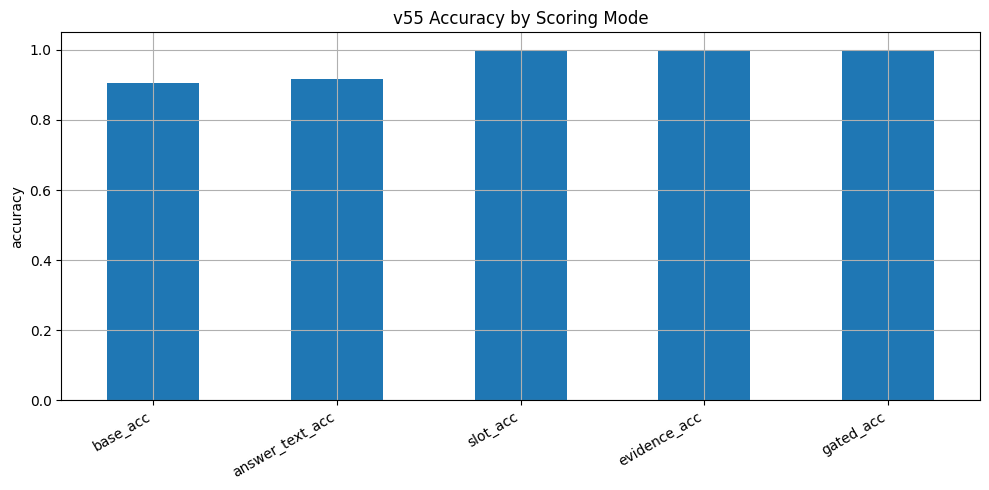

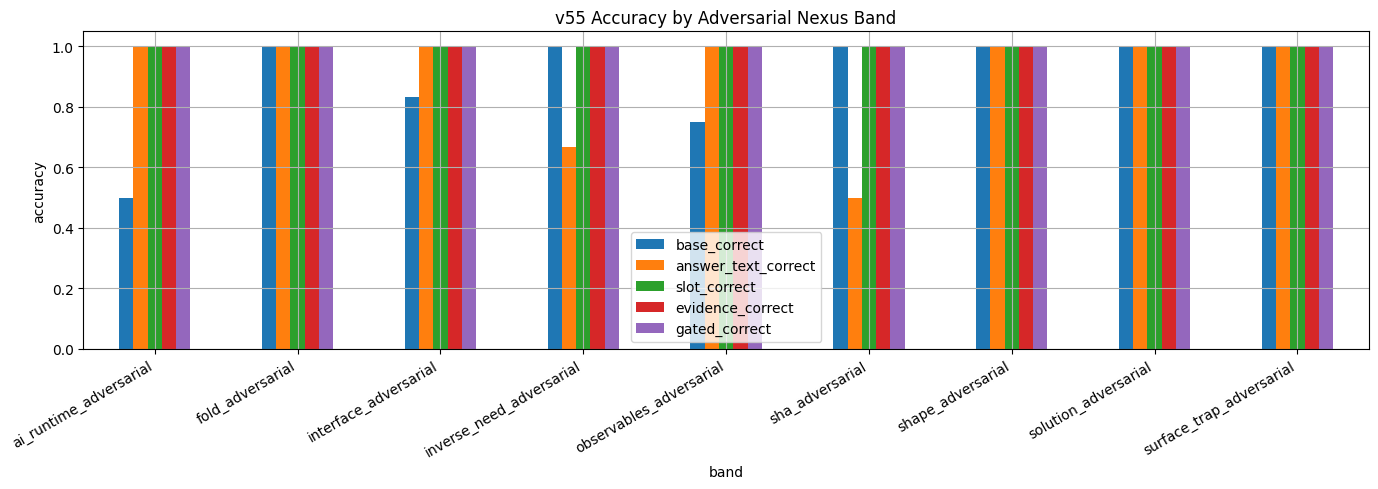

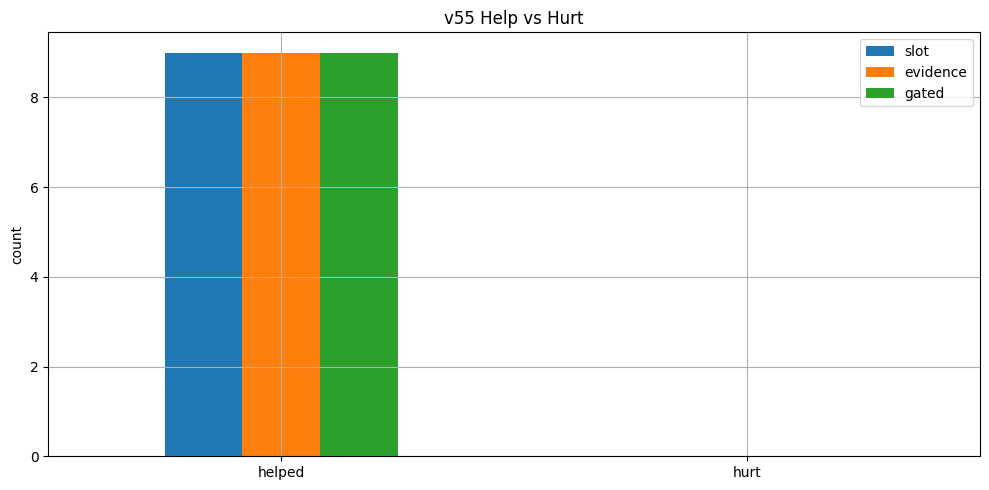

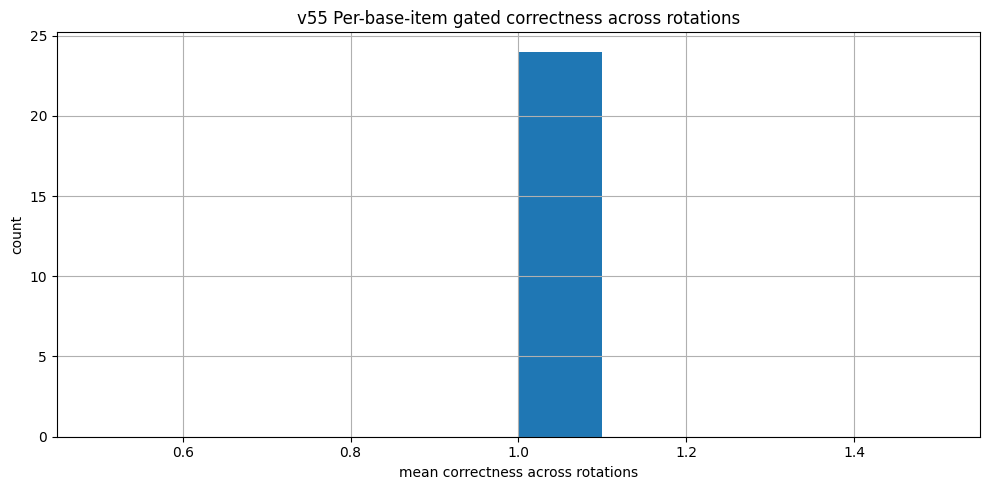

In [9]:
summary[["base_acc","answer_text_acc","slot_acc","evidence_acc","gated_acc"]].T.plot(kind="bar",legend=False)
plt.title("v55 Accuracy by Scoring Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

by_band.set_index("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].plot(kind="bar", figsize=(14,5))
plt.title("v55 Accuracy by Adversarial Nexus Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "slot":[results_df.slot_helped.sum(),results_df.slot_hurt.sum()],
    "evidence":[results_df.evidence_helped.sum(),results_df.evidence_hurt.sum()],
    "gated":[results_df.gated_helped.sum(),results_df.gated_hurt.sum()],
},index=["helped","hurt"]).plot(kind="bar")
plt.title("v55 Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

by_base_item["gated_correct"].hist(bins=10)
plt.title("v55 Per-base-item gated correctness across rotations")
plt.xlabel("mean correctness across rotations")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [10]:
for row_id in interesting["id"].head(24):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][[
        "id","base_id","band","gold_choice","base_choice","base_correct","base_margin",
        "answer_text_choice","answer_text_correct","answer_text_margin",
        "slot_choice","slot_correct","slot_margin","slot_delta_vs_base",
        "evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base",
        "gated_choice","gated_correct","gate_reason"
    ]])
    print("NEED SLOT:")
    print(results_df[results_df.id==row_id]["need_slot_text"].iloc[0])
    display(evidence_tables[row_id].sort_values("evidence_score", ascending=False))


CASE: adv_car_01__rot0


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125,"a readable driver surface: wheel, pedals, seat...",1,3.380859,...,1,3.203378,3.23158,"a readable driver surface: wheel, pedals, seat...",1,2.002406,3.23158,"a readable driver surface: wheel, pedals, seat...",1,override_text_compiled_slot_agree


NEED SLOT:
required_operation: collapse hidden vehicle mechanics into a usable driver control surface
preserved_function: preserve human control of motion, steering, speed, and safety
boundary_conditions: visible readable interface; controls reachable by driver; not merely a category label
anti_fits: semantic category called vehicle; engine noun inventory; transportation culture symbol
admissible_shape: readable driver surface: wheel, pedals, seat, motion
failure_modes: noun-label answer; internal part list; cultural symbol
source: compiler_root


,choice_idx,choice,adm_cos,pos_cos,neg_cos,adm_j,pos_j,neg_j,slot_score,letter_score,answer_text_score,letter_z,text_z,slot_z,evidence_score
1,1,"a readable driver surface: wheel, pedals, seat...",0.887533,0.730515,0.260948,0.388889,0.280000,0.000000,2.481651,-23.828125,-2.486328,0.251293,1.702180,1.726748,1.570604
0,0,a semantic category called vehicle,0.404060,0.483798,0.740250,0.047619,0.074074,0.250000,-0.749930,-18.703125,-6.722656,1.529186,-0.850649,-0.521806,-0.431802
2,2,a detailed list of engine nouns,0.256682,0.272647,0.541784,0.000000,0.000000,0.111111,-0.721727,-28.078125,-5.867188,-0.808423,-0.335140,-0.502182,-0.474341
3,3,a symbol of transportation culture,0.258743,0.236515,0.577545,0.000000,0.000000,0.187500,-1.009994,-28.734375,-6.167969,-0.972056,-0.516392,-0.702760,-0.664461


CASE: adv_car_01__rot2


...

,choice_idx,choice,adm_cos,pos_cos,neg_cos,adm_j,pos_j,neg_j,slot_score,letter_score,answer_text_score,letter_z,text_z,slot_z,evidence_score
2,2,distributed constraint bias shaping the next-t...,0.806876,0.697482,0.149303,0.35,0.259259,0.000000,2.487186,-20.265625,-2.669922,0.240988,1.672019,1.687003,1.537157
1,1,a non-computational object,0.226581,0.308823,0.270122,0.00,0.000000,0.230769,-0.290000,-16.968750,-6.531250,1.520194,-0.145983,-0.196701,-0.007260
0,0,a file of exact paragraphs,0.051065,0.229232,0.583827,0.00,0.034483,0.230769,-1.171050,-22.640625,-7.636719,-0.680526,-0.666463,-0.794297,-0.738178
3,3,a list of final answers,0.250522,0.202371,0.620543,0.00,0.000000,0.230769,-1.026136,-23.671875,-8.046875,-1.080657,-0.859574,-0.696005,-0.791719


CASE: adv_weight_01__rot3


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
91,adv_weight_01__rot3,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,0.875,distributed constraint bias shaping the next-t...,1,3.203125,...,1,2.777186,2.777186,distributed constraint bias shaping the next-t...,1,1.55566,2.777186,distributed constraint bias shaping the next-t...,1,override_text_compiled_slot_agree


NEED SLOT:
required_operation: identify weights as distributed constraints shaping next-token transitions
preserved_function: preserve learned bias and context-sensitive generation rather than stored answer lookup
boundary_conditions: distributed constraint field; shapes emission probabilities; not exact paragraph storage
anti_fits: list of final answers; file of exact paragraphs; non-computational object
admissible_shape: distributed constraint bias shaping the next-token fold
failure_modes: answer-list interpretation; stored paragraph interpretation
source: compiler_root


,choice_idx,choice,adm_cos,pos_cos,neg_cos,adm_j,pos_j,neg_j,slot_score,letter_score,answer_text_score,letter_z,text_z,slot_z,evidence_score
1,1,distributed constraint bias shaping the next-t...,0.806876,0.697482,0.149303,0.35,0.259259,0.000000,2.487186,-19.875000,-3.027344,0.635689,1.626702,1.687003,1.560766
0,0,a non-computational object,0.226581,0.308823,0.270122,0.00,0.000000,0.230769,-0.290000,-19.000000,-6.230469,1.077907,0.015717,-0.196701,0.005106
2,2,a list of final answers,0.250522,0.202371,0.620543,0.00,0.000000,0.230769,-1.026136,-21.453125,-7.992188,-0.161883,-0.870325,-0.696005,-0.703605
3,3,a file of exact paragraphs,0.051065,0.229232,0.583827,0.00,0.034483,0.230769,-1.171050,-24.203125,-7.796875,-1.551712,-0.772094,-0.794297,-0.862267


## Readout

v55 lock target:

$$
\text{gated\_acc} \ge 0.979167
$$

and:

$$
\text{gated\_hurt}=0
$$

Stronger target:

$$
\text{slot\_acc} > 0.90
$$

If v55 locks, the result is:

$$
\boxed{\text{the compiler slot has the right geometry; now train a model to emit that geometry}}
$$

The next fold is a slot-builder dataset:

$$
(\text{prompt},\text{compiler slot}) \rightarrow \text{slot-builder model}
$$
